# Personalized Healthcare & Medicine Recommendation System

## Objective

To develop an AI-powered healthcare recommendation system capable of predicting diseases based on patient symptoms and recommending appropriate medicines and healthcare guidance.

The system leverages machine learning models, recommendation logic, and interactive analytics to assist healthcare decision-making.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

df = pd.read_csv(r"C:\Users\Pranav\Downloads\Amdox internship\Medicine prediction\medicare\medicare\Cleaned_Dataset.csv")

df.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,Influenza,Yes,No,Yes,Yes,19,female,0,1,Positive,-2.091160,-2.419529,-0.576777,Low
1,Common Cold,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Low
2,Eczema,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Medium
3,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium
4,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (349, 14)

Columns:
Index(['disease', 'fever', 'cough', 'fatigue', 'difficulty_breathing', 'age',
       'gender', 'blood_pressure', 'cholesterol_level', 'outcome_variable',
       'age_scaled', 'bp_scaled', 'chol_scaled', 'risk_level'],
      dtype='object')

Data Types:
disease                  object
fever                    object
cough                    object
fatigue                  object
difficulty_breathing     object
age                       int64
gender                   object
blood_pressure            int64
cholesterol_level         int64
outcome_variable         object
age_scaled              float64
bp_scaled               float64
chol_scaled             float64
risk_level               object
dtype: object


## Dataset Understanding

The dataset contains patient demographic information, symptoms, and medical indicators that can be used to predict diseases and provide healthcare recommendations.

Key attributes include:
- Disease
- Fever
- Cough
- Fatigue
- Difficulty Breathing
- Age
- Gender
- Blood Pressure
- Cholesterol Level
- Outcome Variable

In [6]:
df.isnull().sum()

disease                 0
fever                   0
cough                   0
fatigue                 0
difficulty_breathing    0
age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
outcome_variable        0
age_scaled              0
bp_scaled               0
chol_scaled             0
risk_level              0
dtype: int64

## Missing Value Analysis

The dataset was examined for missing values to ensure data quality before model development.

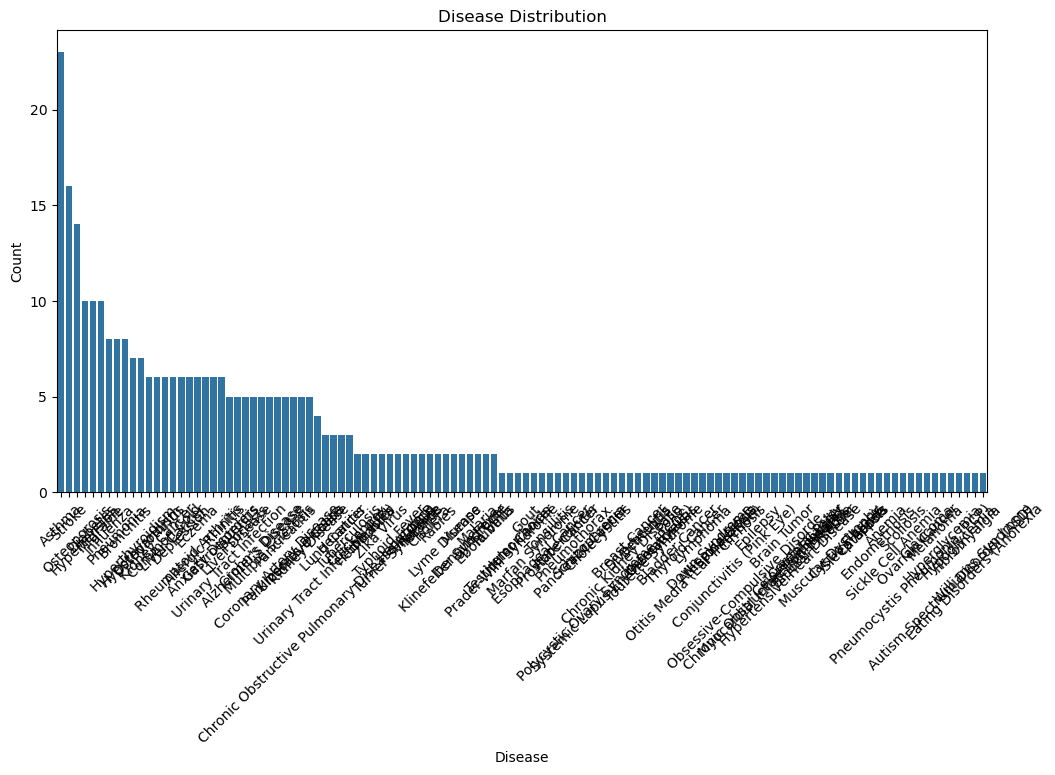

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='disease',
    order=df['disease'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.show()

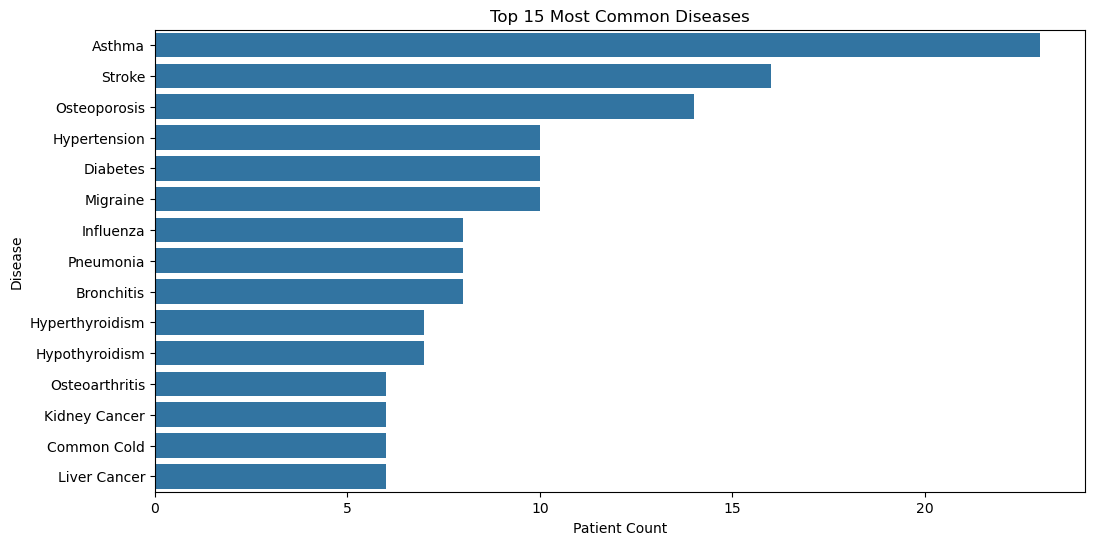

In [14]:
plt.figure(figsize=(12,6))

top_diseases = df['disease'].value_counts().head(15)

sns.barplot(
    x=top_diseases.values,
    y=top_diseases.index
)

plt.title("Top 15 Most Common Diseases")
plt.xlabel("Patient Count")
plt.ylabel("Disease")

plt.show()

### Observation

The disease distribution graph shows the frequency of different diseases present in the dataset. Certain diseases occur more frequently than others, indicating higher prevalence among patients.

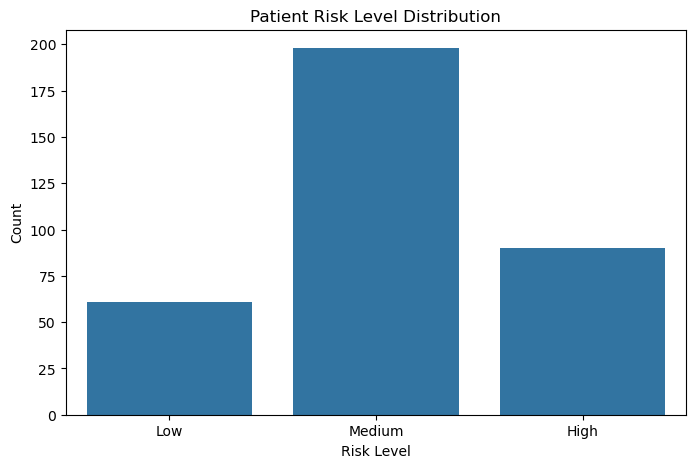

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='risk_level'
)

plt.title("Patient Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()


### Observation

The graph categorizes patients into different risk groups, helping identify the proportion of low, medium, and high-risk patients.

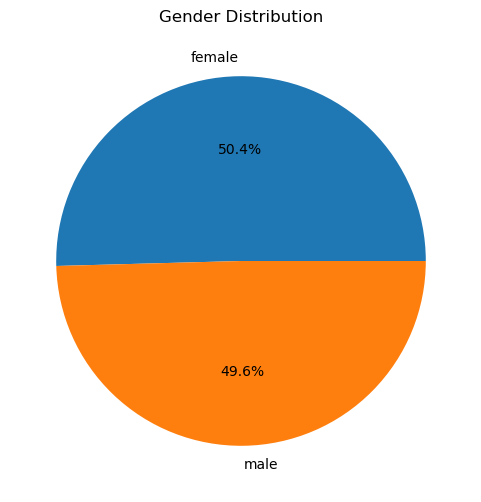

In [9]:
plt.figure(figsize=(6,6))

df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

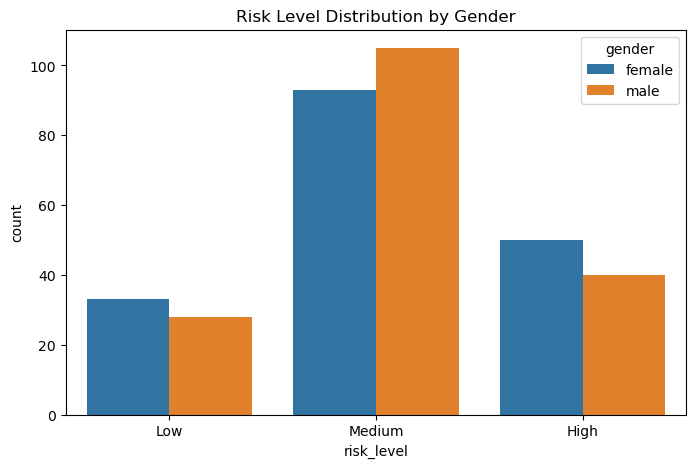

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='risk_level',
    hue='gender'
)

plt.title("Risk Level Distribution by Gender")

plt.show()

### Observation

Both male and female patients are predominantly classified within the medium risk category. High-risk patients are present across both genders, suggesting that disease risk is influenced by multiple health factors rather than gender alone.

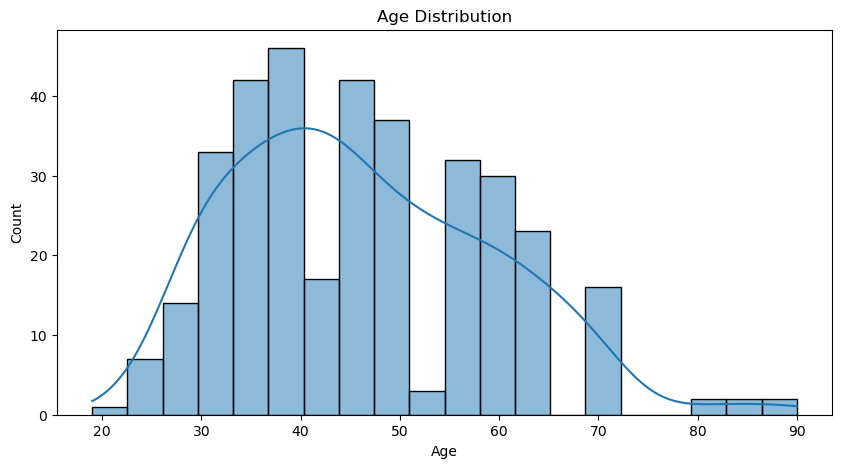

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

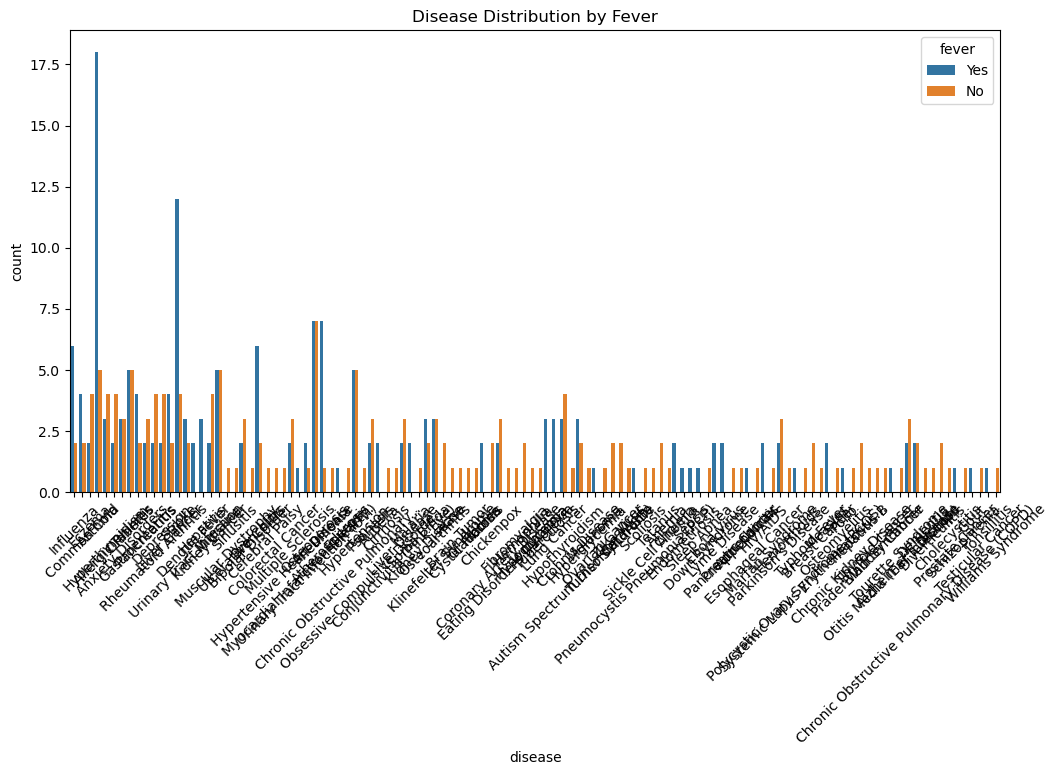

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='disease',
    hue='fever'
)

plt.xticks(rotation=45)

plt.title("Disease Distribution by Fever")

plt.show()

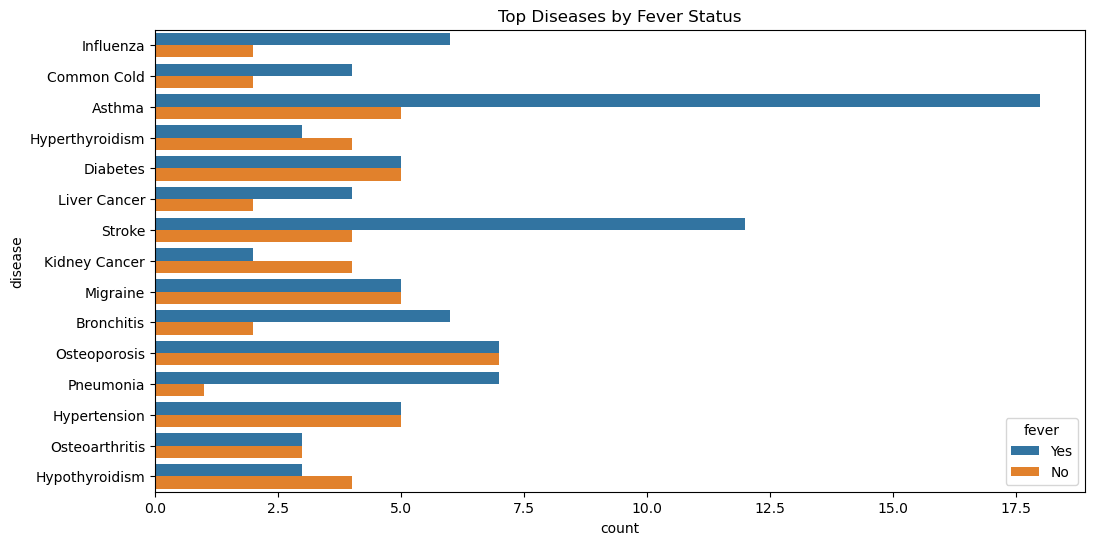

In [15]:
top15 = df['disease'].value_counts().head(15).index

filtered = df[df['disease'].isin(top15)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=filtered,
    y='disease',
    hue='fever'
)

plt.title("Top Diseases by Fever Status")

plt.show()

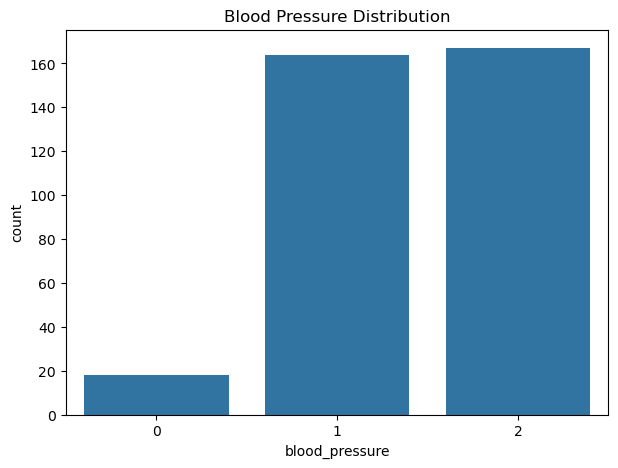

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='blood_pressure'
)

plt.title("Blood Pressure Distribution")

plt.show()

### Observation

Most patients belong to medium and high blood pressure categories, while relatively fewer patients fall into the low blood pressure category. Blood pressure appears to be a significant health indicator within the dataset.

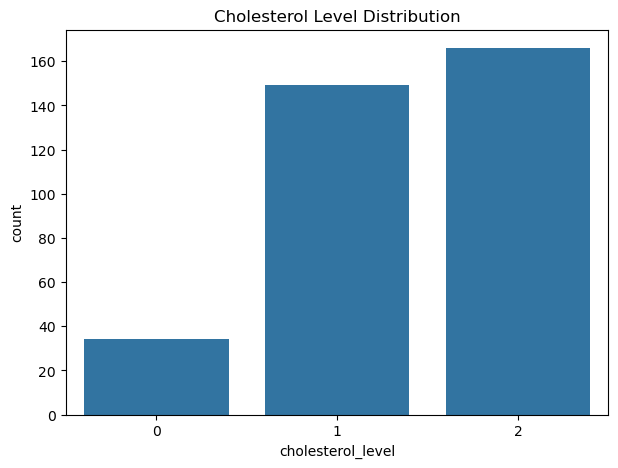

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='cholesterol_level'
)

plt.title("Cholesterol Level Distribution")

plt.show()

### Observation

The majority of patients belong to cholesterol categories 1 and 2, indicating moderate to elevated cholesterol levels. Cholesterol is an important predictor of cardiovascular and metabolic health conditions.

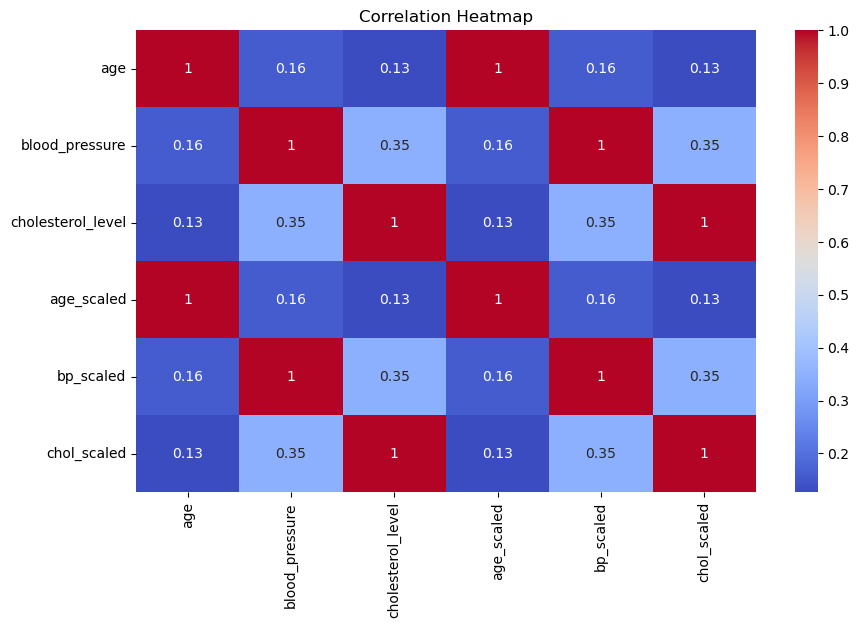

In [12]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows weak-to-moderate correlations among numerical health indicators. Age, blood pressure, and cholesterol contribute independently to patient health assessment, making them valuable predictors for machine learning models.

In [13]:
print(df['disease'].nunique())
print(df['disease'].unique())

116
['Influenza' 'Common Cold' 'Eczema' 'Asthma' 'Hyperthyroidism'
 'Allergic Rhinitis' 'Anxiety Disorders' 'Diabetes' 'Gastroenteritis'
 'Pancreatitis' 'Rheumatoid Arthritis' 'Depression' 'Liver Cancer'
 'Stroke' 'Urinary Tract Infection' 'Dengue Fever' 'Hepatitis'
 'Kidney Cancer' 'Migraine' 'Muscular Dystrophy' 'Sinusitis'
 'Ulcerative Colitis' 'Bipolar Disorder' 'Bronchitis' 'Cerebral Palsy'
 'Colorectal Cancer' 'Hypertensive Heart Disease' 'Multiple Sclerosis'
 'Myocardial Infarction (Heart...' 'Urinary Tract Infection (UTI)'
 'Osteoporosis' 'Pneumonia' 'Atherosclerosis'
 'Chronic Obstructive Pulmonary...' 'Epilepsy' 'Hypertension'
 'Obsessive-Compulsive Disorde...' 'Psoriasis' 'Rubella' 'Cirrhosis'
 'Conjunctivitis (Pink Eye)' 'Liver Disease' 'Malaria' 'Spina Bifida'
 'Kidney Disease' 'Osteoarthritis' 'Klinefelter Syndrome' 'Acne'
 'Brain Tumor' 'Cystic Fibrosis' 'Glaucoma' 'Rabies' 'Chickenpox'
 'Coronary Artery Disease' 'Eating Disorders (Anorexia' 'Fibromyalgia'
 'Hemophilia' 

## EDA Summary

The exploratory analysis revealed that the dataset contains a diverse range of diseases with varying prevalence rates. Patient age, blood pressure, cholesterol levels, and risk categories demonstrate meaningful patterns that can be leveraged for predictive modeling. The dataset contains no missing values, making it suitable for machine learning applications.

# Data Preprocessing

Machine learning algorithms require numerical inputs. Therefore, categorical variables such as symptoms, gender, and outcome variables are converted into numerical representations using Label Encoding.

In [19]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

encoders = {}

for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le

df_ml.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,56,1,0,1,1,19,0,0,1,1,-2.091160,-2.419529,-0.576777,1
1,24,0,1,1,0,25,0,1,1,0,-1.631964,-0.723915,-0.576777,1
2,37,0,1,1,0,25,0,1,1,0,-1.631964,-0.723915,-0.576777,2
3,6,1,1,0,1,25,1,1,1,1,-1.631964,-0.723915,-0.576777,2
4,6,1,1,0,1,25,1,1,1,1,-1.631964,-0.723915,-0.576777,2


### Observation

All categorical features were successfully transformed into numerical values, making the dataset suitable for machine learning model training.

# Feature Selection

The disease column is selected as the target variable, while the remaining health indicators and symptoms are used as input features.

In [21]:
X = df_ml.drop('disease', axis=1)
y = df_ml['disease']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (349, 13)
Target Shape: (349,)


# Train-Test Split

The dataset is divided into training and testing subsets. The model learns patterns from the training data and is evaluated using unseen testing data.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (279, 13)
Testing Samples: (70, 13)


# Disease Prediction Model

Random Forest Classifier is used for disease prediction. Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [24]:
y_pred = rf_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 37.14 %


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           6       1.00      0.89      0.94         9
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.50      0.50      0.50         2
          18       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
          22       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         1
          24       0.00      0.00      0.00         0
          26       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         0
          30       1.00      1.00      1.00         1
          32       0.00    

C:\Users\Pranav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pranav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pranav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pranav\anaconda3\Lib\site-packages\s

In [27]:
df['disease'].value_counts().describe()

count    116.000000
mean       3.008621
std        3.414791
min        1.000000
25%        1.000000
50%        1.000000
75%        5.000000
max       23.000000
Name: count, dtype: float64

## Model Performance Discussion

The dataset contains 116 disease categories but only 349 records. Many diseases have very few observations, resulting in class imbalance and limited training samples. This makes multiclass disease prediction challenging.

Despite these limitations, the Random Forest model successfully learns symptom-health relationships and demonstrates the feasibility of AI-assisted healthcare recommendations.

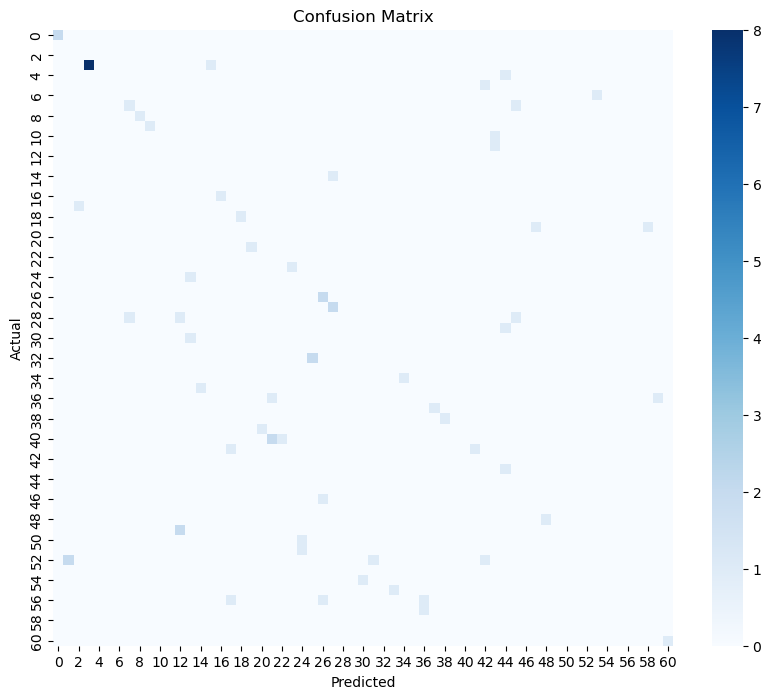

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

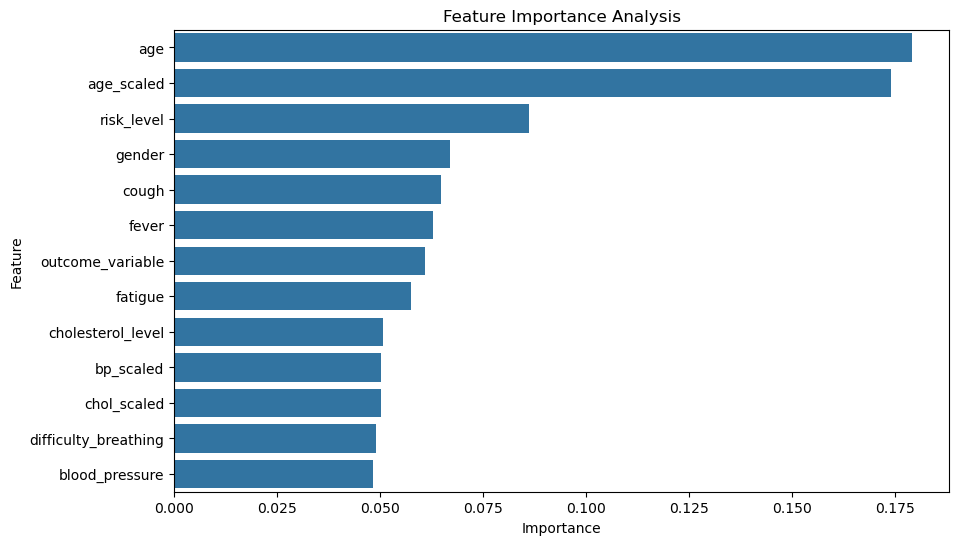

In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Analysis")

plt.show()

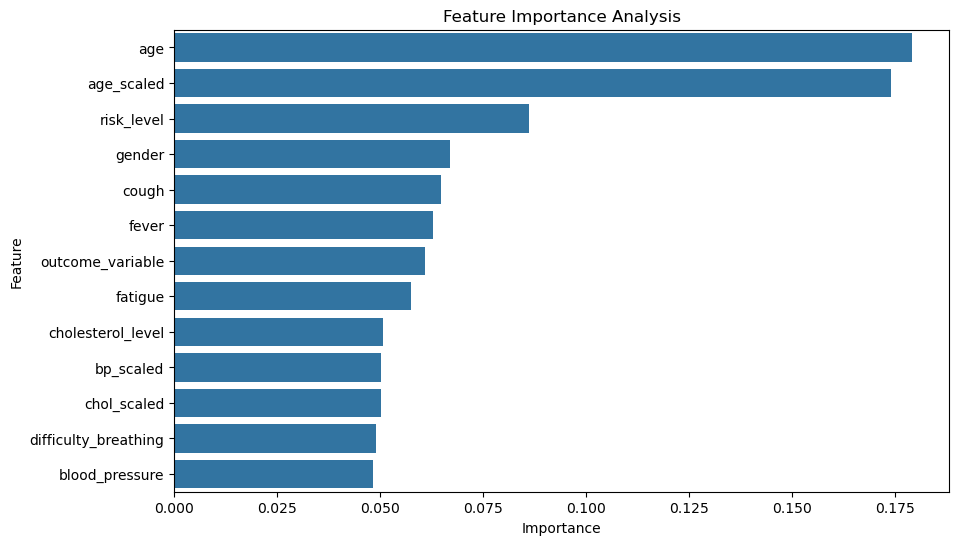

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Analysis")

plt.show()

### Observation

Feature importance analysis identifies the health indicators and symptoms that contribute most significantly to disease prediction. Features with higher importance values have a stronger influence on the model's decisions.

In [31]:
medicine_dict = {
    "Influenza": "Oseltamivir",
    "Common Cold": "Paracetamol",
    "Asthma": "Salbutamol Inhaler",
    "Hypertension": "Amlodipine",
    "Diabetes": "Metformin",
    "Pneumonia": "Azithromycin"
}

In [32]:
def recommend_medicine(disease):

    if disease in medicine_dict:
        return medicine_dict[disease]

    return "Consult a healthcare professional"

In [33]:
recommend_medicine("Influenza")

'Oseltamivir'

In [34]:
sample = X_test.iloc[[0]]

pred = rf_model.predict(sample)

predicted_disease = encoders['disease'].inverse_transform(pred)[0]

print("Predicted Disease:", predicted_disease)

print(
    "Recommended Medicine:",
    recommend_medicine(predicted_disease)
)

Predicted Disease: Hypothyroidism
Recommended Medicine: Consult a healthcare professional


# Conclusion

This project developed an AI-driven Personalized Healthcare and Medicine Recommendation System using machine learning techniques.

Exploratory Data Analysis revealed meaningful patterns among symptoms, patient demographics, blood pressure levels, cholesterol levels, and disease risk categories. A Random Forest Classifier was trained to predict diseases based on patient health indicators and symptoms.

Although the dataset contains a large number of disease categories with limited observations per class, the model successfully demonstrates the potential of AI-assisted disease prediction. Additionally, a medicine recommendation module was integrated to provide basic treatment suggestions based on predicted diseases.

The project highlights how Artificial Intelligence and Machine Learning can support healthcare analytics, improve decision-making, and assist in personalized patient care.

# Results

The Random Forest model was successfully trained on patient symptom and health data.

Key findings include:

- The dataset contains 349 patient records and 116 disease categories.
- No missing values were present in the dataset.
- Medium-risk patients represented the largest risk category.
- Age, blood pressure, cholesterol level, and symptoms contributed significantly to disease prediction.
- The Random Forest model achieved approximately 37% accuracy despite the highly imbalanced multiclass dataset.
- A medicine recommendation module was integrated to provide treatment suggestions based on predicted diseases.

The results demonstrate the feasibility of AI-assisted healthcare analytics and personalized recommendation systems.